In [ ]:
import cdsapi

c = cdsapi.Client()
print("CDS API connected successfully!")

2025-09-22 21:44:22,374 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-22 21:44:22,376 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


CDS API connected successfully!


In [ ]:
import cdsapi

# Initialize client
c = cdsapi.Client()

# Hungary bounding box (North, West, South, East)
hungary_area = [49.6, 16.1, 45.7, 22.9]  # North, West  # South, East

# Request ERA5 single-level data (surface variables)
c.retrieve(
    "reanalysis-era5-single-levels",
    {
        "product_type": "reanalysis",
        "variable": [
            "2m_temperature",  # add more variables if needed
        ],
        "year": "2024",
        "month": "08",  # August
        "day": [f"{d:02d}" for d in range(1, 32)],  # days in August
        "time": [
            "00:00",
            "06:00",
            "12:00",
            "18:00",  # four times daily
        ],
        "area": hungary_area,  # Hungary bounding box
        "format": "netcdf",  # 'netcdf' or 'grib'
    },
    "era5_hungary_august2024.nc",
)

print("Download complete: era5_hungary_august2024.nc")

2025-09-22 21:45:46,764 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-22 21:45:46,765 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-09-22 21:45:47,078 INFO Request ID is c0171e15-9a76-4f2c-85f2-60e42939889a
2025-09-22 21:45:47,160 INFO status has been updated to accepted
2025-09-22 21:46:00,727 INFO status has been updated to running
2025-09-22 21:46:36,981 INFO status has been updated to successful


6ac2e6850bc3f99881c88538935f4f76.nc:   0%|          | 0.00/140k [00:00<?, ?B/s]

Download complete: era5_hungary_august2024.nc


In [ ]:
import xarray as xr

# Open dataset
ds = xr.open_dataset("era5_hungary_august2024.nc")

print(ds)

<xarray.Dataset>
Dimensions:     (valid_time: 124, latitude: 16, longitude: 28)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2024-08-01 ... 2024-08-31T18:00:00
  * latitude    (latitude) float64 49.45 49.2 48.95 48.7 ... 46.2 45.95 45.7
  * longitude   (longitude) float64 16.1 16.35 16.6 16.85 ... 22.35 22.6 22.85
    expver      (valid_time) object ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-22T19:46 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
print(ds["t2m"])  # metadata for 2m temperature

<xarray.DataArray 't2m' (valid_time: 124, latitude: 16, longitude: 28)>
[55552 values with dtype=float32]
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2024-08-01 ... 2024-08-31T18:00:00
  * latitude    (latitude) float64 49.45 49.2 48.95 48.7 ... 46.2 45.95 45.7
  * longitude   (longitude) float64 16.1 16.35 16.6 16.85 ... 22.35 22.6 22.85
    expver      (valid_time) object ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      448
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                 

In [ ]:
temp_c = ds["t2m"] - 273.15

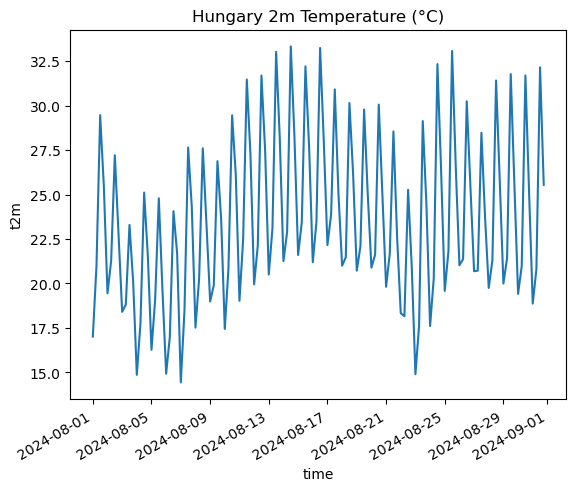

In [ ]:
import matplotlib.pyplot as plt

# Spatial average
temp_avg = temp_c.mean(dim=["latitude", "longitude"])

# Plot time series
temp_avg.plot()
plt.title("Hungary 2m Temperature (°C)")
plt.show()

c:\Users\marti\anaconda3\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


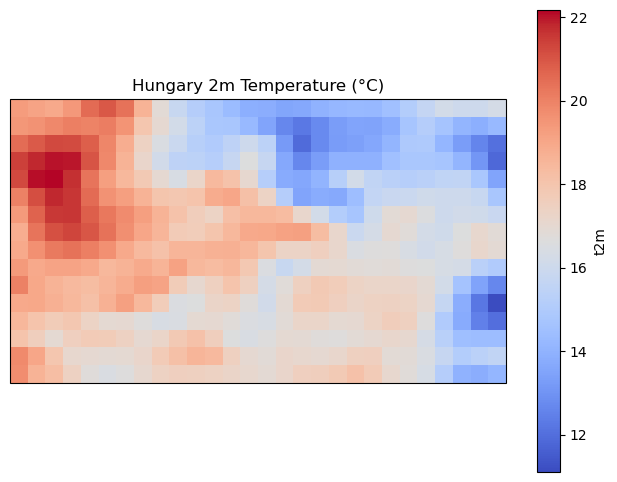

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# Select first timestep
timestep = temp_c.isel(valid_time=0)


plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
timestep.plot(ax=ax, cmap="coolwarm")
ax.coastlines()
ax.set_title("Hungary 2m Temperature (°C)")
plt.show()

In [ ]:
# THESE FILES CANNOT BE OPENED
import cdsapi

c = cdsapi.Client()

hungary_area = [49.6, 16.1, 45.7, 22.9]

years = [2019, 2020, 2021, 2022, 2023, 2024]
months = [f"{m:02d}" for m in range(1, 13)]

for year in years:
    for month in months:
        print(f"Downloading {year}-{month} ...")
        c.retrieve(
            "reanalysis-era5-land",
            {
                "variable": ["2m_temperature"],
                "year": str(year),
                "month": month,
                "day": [f"{d:02d}" for d in range(1, 32)],
                "time": [f"{h:02d}:00" for h in range(24)],
                "area": hungary_area,
                "format": "netcdf",
            },
            f"era5land_hungary_{year}_{month}.nc",
        )

2025-09-22 22:23:34,283 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-22 22:23:34,283 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-09-22 22:23:34,478 INFO Request ID is 55c60545-4cef-4ef1-ad64-8b85c8f5d5fc


2025-09-22 22:23:34,568 INFO status has been updated to accepted
2025-09-22 22:23:43,006 INFO status has been updated to running
2025-09-22 22:23:48,139 INFO status has been updated to accepted
2025-09-22 22:23:55,848 INFO status has been updated to running
2025-09-22 22:25:28,687 INFO status has been updated to successful


bb105cd55c2208d22cfd1aaec6ef4fe3.zip:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

2025-09-22 22:25:30,877 INFO Request ID is 78ccac4a-5ea2-490e-92b3-e3e09c20ba62


2025-09-22 22:25:30,964 INFO status has been updated to accepted
2025-09-22 22:25:39,407 INFO status has been updated to running
2025-09-22 22:27:25,183 INFO status has been updated to successful


...

1176fbb5a6aabd27e92cdd4288986641.zip:   0%|          | 0.00/3.07M [00:00<?, ?B/s]

2025-09-23 01:15:32,044 INFO Request ID is 3670a3ee-34c0-4a71-82d7-a4b484502084
2025-09-23 01:15:32,110 INFO status has been updated to accepted
2025-09-23 01:15:40,505 INFO status has been updated to running
2025-09-23 01:17:26,143 INFO status has been updated to successful


d9ab6c01f5365b7d2cd7b8e7345686d7.zip:   0%|          | 0.00/2.97M [00:00<?, ?B/s]

2025-09-23 01:17:27,592 INFO Request ID is ea8ae29b-5477-4231-ac9f-4af1ecb6e294
2025-09-23 01:17:27,677 INFO status has been updated to accepted
2025-09-23 01:17:41,252 INFO status has been updated to running
2025-09-23 01:19:21,767 INFO status has been updated to successful


8a0b3318f8167df5365356927dc1111b.zip:   0%|          | 0.00/3.04M [00:00<?, ?B/s]

In [ ]:
import cdsapi
import xarray as xr
import pandas as pd
import glob
import os

# Initialize CDS API
c = cdsapi.Client()

# Hungary bounding box: [North, West, South, East]
hungary_area = [49.6, 16.1, 45.7, 22.9]

# Ensure output directory exists
os.makedirs("./era5/", exist_ok=True)

# Years and months to download
years = range(2019, 2025)  # 2019 to 2024
months = [f"{m:02d}" for m in range(1, 13)]

# Download NetCDF files month by month
for year in years:
    for month in months:
        filename = f"./era5/era5_hungary_{year}_{month}.nc"
        if not os.path.exists(filename):  # skip if already downloaded
            print(f"Downloading {year}-{month} ...")
            c.retrieve(
                "reanalysis-era5-single-levels",
                {
                    "product_type": "reanalysis",
                    "variable": ["2m_temperature"],
                    "year": str(year),
                    "month": month,
                    "day": [f"{d:02d}" for d in range(1, 32)],
                    "time": [f"{h:02d}:00" for h in range(24)],  # hourly
                    "area": hungary_area,
                    "format": "netcdf",
                },
                filename,
            )

2025-09-23 15:04:46,373 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-23 15:04:46,374 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


2025-09-23 15:04:46,649 INFO Request ID is dd4abc19-5eb7-4589-bff9-fce46d2fb99e
2025-09-23 15:04:46,709 INFO status has been updated to accepted
2025-09-23 15:04:55,246 INFO status has been updated to successful


aef1c7dbeff018fcd00fa21200df4cae.nc:   0%|          | 0.00/716k [00:00<?, ?B/s]

2025-09-23 15:04:56,280 INFO Request ID is 5a11ec66-5477-4dcd-984a-233f58c9a5c0
2025-09-23 15:04:56,353 INFO status has been updated to accepted
2025-09-23 15:05:04,700 INFO status has been updated to running
2025-09-23 15:05:45,993 INFO status has been updated to successful


6207d55c949ffba90783590dd38b55e9.nc:   0%|          | 0.00/666k [00:00<?, ?B/s]

...

2025-09-24 20:51:54,130 INFO Request ID is 2cb034d9-26d0-46a4-966c-8f99f08d37d2
2025-09-24 20:51:54,209 INFO status has been updated to accepted
2025-09-24 20:52:02,725 INFO status has been updated to running
2025-09-24 20:52:44,149 INFO status has been updated to successful


76d79b348a33269a367394cbf79bfb11.nc:   0%|          | 0.00/697k [00:00<?, ?B/s]

2025-09-24 20:52:45,216 INFO Request ID is 0b4c8116-19de-4be7-9fc2-d03001dad5ff
2025-09-24 20:52:45,274 INFO status has been updated to accepted
2025-09-24 20:52:58,856 INFO status has been updated to running
2025-09-24 20:53:35,139 INFO status has been updated to successful


d38d5185f4ca0400824fa3517e4bef2d.nc:   0%|          | 0.00/717k [00:00<?, ?B/s]

Done! CSV saved as 'hungary_hourly_temperature_2019_2024.csv'


In [ ]:
import glob
import xarray as xr

# Open all downloaded files as a single xarray dataset
files = sorted(glob.glob("./era5/era5_hungary_*.nc"))
ds = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4")

# Convert 2m temperature from Kelvin to Celsius
temp_c = ds["t2m"] - 273.15

# Average over latitude and longitude (Hungary)
temp_avg = temp_c.mean(dim=["latitude", "longitude"])

# Convert to pandas DataFrame
df = temp_avg.to_dataframe(name="temperature").reset_index()
df.rename(columns={"time": "datetime"}, inplace=True)

# Save to CSV
df.to_csv("hungary_hourly_temperature_2019_2024.csv", index=False)

print("Done! CSV saved as 'hungary_hourly_temperature_2019_2024.csv'")

Done! CSV saved as 'hungary_hourly_temperature_2019_2024.csv'


In [6]:
# Calculate volatility (standard deviation) over latitude and longitude for each time step
temp_volatility = temp_c.std(dim=["latitude", "longitude"])

# Convert to pandas DataFrame
df_volatility = temp_volatility.to_dataframe(name="volatility").reset_index()
df_volatility.rename(columns={"time": "datetime"}, inplace=True)

# Save to CSV
df_volatility.to_csv("hungary_hourly_temperature_volatility_2019_2024.csv", index=False)

print("Done! CSV saved as 'hungary_hourly_temperature_volatility_2019_2024.csv'")

Done! CSV saved as 'hungary_hourly_temperature_volatility_2019_2024.csv'
